**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("data.table")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [2]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "*XY_gain*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.tsv 


**Import table**

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY_gain = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99102   668


Variant_ID,Delta,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP,AC0449:TIGD:CENPB,AC0495:CTCF/CTCFL:C2H2_ZF,AC0576:ZSCAN/ZNF:C2H2_ZF,AC0629:DBP/HLF:bZIP,AC0631:ATF/CREB:bZIP,AC0634:CREB/JUND:bZIP,AC0688:HSF:HSF,AC0148:BPTF/ZNF:Unknown,AC0162:ZNF:C2H2_ZF,AC0258:NRL/MAFG:bZIP,AC0313:ZBED:BED_ZF,AC0314:ZNF385D:C2H2_ZF,AC0358:ZNF:C2H2_ZF,AC0374:ARID5B:ARID/BRIGHT,AC0460:IRX:Homeodomain,AC0461:ASCL:bHLH,AC0555:NRF:Unknown,AC0597:SMAD:SMAD,AC0632:CREB:bZIP,AC0070:ZNF:C2H2_ZF,AC0144:ZNF:C2H2_ZF,AC0256:MAFF/MAF:bZIP,AC0271:PROX:Prospero,AC0410:ZNF:C2H2_ZF,AC0476:IRX:Homeodomain,AC0085:ZNF:C2H2_ZF,AC0110:NR2F/NR1H:Nuclear_receptor,AC0238:PBX/PKNOX:Homeodomain,AC0259:MAFG/MAFF:bZIP,AC0362:FOXG/FOXK:Forkhead,AC0584:ZSCAN:C2H2_ZF,AC0603:ZNF:C2H2_ZF,AC0047:ZNF:C2H2_ZF,AC0074:ZBTB/TWIST:C2H2_ZF,AC0077:LYL/OLIG:bHLH,AC0080:ZNF:C2H2_ZF,AC0081:SCRT:C2H2_ZF,AC0149:ZNF:C2H2_ZF,AC0193:ZNF:C2H2_ZF,AC0194:CTCF:C2H2_ZF,AC0450:ZBTB:C2H2_ZF,AC0579:ZNF:C2H2_ZF,AC0587:ZNF:C2H2_ZF,AC0492:TBX/T:T-box,AC0111:NR1H:Nuclear_receptor,AC0161:ZNF:C2H2_ZF,AC0475:TP:p53,AC0485:FOSL:bZIP,AC0599:ZKSCAN:C2H2_ZF,"AC0089:POU4F:Homeodomain,POU","AC0101:POU3F/POU2F:Homeodomain,POU",AC0184:ZNF:C2H2_ZF,"AC0230:POU2F/ZNF:Homeodomain,POU",AC0651:ZNF:C2H2_ZF,AC0039:FOXD/FOXK:Forkhead,AC0268:GMEB:SAND,AC0578:ZNF:C2H2_ZF,AC0628:CEBPB/CEBPE:bZIP,AC0045:ZNF:C2H2_ZF,"AC0076:ERF::FIGLA/ETV2::FIGLA:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0127:TCF7L/LEF:Sox,AC0133:NR6A:Nuclear_receptor,"AC0636:POU5F/NANOG:Homeodomain,POU",AC0124:RARA/RARG:Nuclear_receptor,AC0231:ZNF:C2H2_ZF,AC0233:ZNF:C2H2_ZF,AC0401:ZNF:C2H2_ZF,AC0513:ZNF:C2H2_ZF,AC0559:ZNF:C2H2_ZF,AC0594:ZNF:C2H2_ZF,AC0200:ZNF:C2H2_ZF,AC0202:ZNF:C2H2_ZF,"AC0483:PAX:Homeodomain,Paired_box","AC0484:PAX:Homeodomain,Paired_box",AC0494:ZIC/GLIS:C2H2_ZF,AC0367:ZNF:C2H2_ZF,AC0512:YY:C2H2_ZF,AC0213:ZNF:C2H2_ZF,AC0237:ZNF:C2H2_ZF,AC0260:IRX:Homeodomain,AC0481:ZNF:C2H2_ZF,AC0504:ZNF:C2H2_ZF,"AC0515:PAX:Homeodomain,Paired_box",AC0046:BACH/NFE:bZIP,AC0096:PBX/HOXA:Homeodomain,AC0098:MEIS/PBX:Homeodomain,AC0113:RARA/ESRRA:Nuclear_receptor,AC0115:NR1I/NR1H:Nuclear_receptor,AC0551:CENPB:CENPB,AC0568:ZNF:C2H2_ZF,AC0049:JUND/JUN:bZIP,AC0234:ZNF:C2H2_ZF,AC0269:FOXN:Forkhead,AC0366:ZNF:C2H2_ZF,AC0488:TBX:T-box,AC0511:YY/ZFP:C2H2_ZF,AC0192:ZIK:C2H2_ZF,AC0024:POU3F/HESX:Homeodomain,AC0165:ZNF:C2H2_ZF,AC0300:ZNF:C2H2_ZF,AC0118:THRA/THRB:Nuclear_receptor,AC0120:THRB:Nuclear_receptor,AC0122:ESR/ESRRA:Nuclear_receptor,AC0123:NR1D/RORC:Nuclear_receptor,AC0155:ZNF:C2H2_ZF,AC0257:ZNF:C2H2_ZF,AC0289:RFX/MXI:RFX,AC0390:ZFP:C2H2_ZF,AC0666:IRF:IRF,AC0009:DUXA/DUX:Homeodomain,AC0163:NR1D:Nuclear_receptor,AC0502:ZNF:C2H2_ZF,AC0520:ZNF/EGR:C2H2_ZF,AC0581:ZNF:C2H2_ZF,AC0591:ZNF:C2H2_ZF,AC0655:RUNX:Runt,AC0075:MYOD/MYOG:bHLH,AC0182:ZNF:C2H2_ZF,AC0108:RXRG/RARB:Nuclear_receptor,AC0136:NR2E:Nuclear_receptor,AC0222:ZNF/ZFP:C2H2_ZF,AC0507:ZNF:C2H2_ZF,AC0353:ZSCAN:C2H2_ZF,AC0550:GCM:GCM,AC0557:ZNF:C2H2_ZF,AC0196:ZNF:C2H2_ZF,AC0284:DMRT/DMRTA:DM,AC0641:ETV/ETS:Ets,AC0642:SPIB/SPI:Ets,AC0275:MYB/MYBL:Myb/SANT,AC0010:PROP/ALX:Homeodomain,AC0028:ZNF:C2H2_ZF,AC0109:ZNF:C2H2_ZF,AC0505:ZSCAN:C2H2_ZF,AC0589:ZNF:C2H2_ZF,AC0487:TBX/T:T-box,AC0530:ZSCAN/KLF:C2H2_ZF,AC0169:ZNF:C2H2_ZF,AC0396:MYRF:Ndt80/PhoG,AC0549:GCM:GCM,AC0570:ZNF:C2H2_ZF,AC0583:ZNF:C2H2_ZF,AC0595:ZNF:C2H2_ZF,AC0086:MEIS/PKNOX:Homeodomain,AC0459:SIX/ZNF:Homeodomain,AC0025:ZNF:C2H2_ZF,AC0677:BCL11A/IRF:C2H2_ZF,"AC0102:POU2F/POU3F:Homeodomain,POU",AC0180:ZNF:C2H2_ZF,AC0430:ZNF:C2H2_ZF,AC0531:ZNF:C2H2_ZF,AC0019:TLX/PAX:Homeodomain,AC0226:ZNF:C2H2_ZF,AC0413:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0050:ZSCAN5C:C2H2_ZF,AC0051:BATF/IRF:bZIP,AC0135:NR2E:Nuclear_receptor,AC0468:ZNF:C2H2_ZF,AC0590:ZNF:C2H2_ZF,AC0352:ZNF:C2H2_ZF,AC0387:ZFP:C2H2_ZF,AC0510:YY/MZF:C2H2_ZF,AC0388:ZNF:C2H2_ZF,AC0094:NR1H/WT:Nuclear_receptor,AC0205:ZNF:C2H2_ZF,AC0206:

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xgb_gain_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 66001932        7


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0629:DBP/HLF:bZIP,0.1358403,6.198104,0.695873,0.001305,chr4:74487586:A:G:C
2,AC0629:DBP/HLF:bZIP,0.1076249,6.198104,0.695873,0.001305,chr9:135685432:G:G:C
3,AC0629:DBP/HLF:bZIP,0.1015119,6.198104,0.695873,0.001305,chr1:173251490:G:G:C


In [7]:
summ_gain_motif <- dat_xgb_gain_shap %>%
  group_by(variable) %>%
  summarise(
    n         = n(),
    mean_shap = mean(rfvalue),
    median_shap = median(rfvalue),
    sd_shap   = sd(rfvalue),
    frac_pos  = mean(rfvalue > 0),
    frac_neg  = mean(rfvalue < 0),
    .groups   = "drop"
  ) %>%
  mutate(direction_gain = case_when(
    mean_shap > 0  ~ "activator_like_gain",
    mean_shap < 0  ~ "repressor_like_gain",
    TRUE           ~ "neutral_gain"
  ))


In [8]:
# Quick look at top candidates
summ_gain_motif %>%
  arrange(desc(mean_shap)) %>%
  head(20)   # top activator-like in gain

variable,n,mean_shap,median_shap,sd_shap,frac_pos,frac_neg,direction_gain
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0172:ZNF:C2H2_ZF,99102,0.3426665,0,1.502768,0.06340942,0,activator_like_gain
AC0583:ZNF:C2H2_ZF,99102,0.3157249,0,1.477925,0.05433795,0,activator_like_gain
AC0504:ZNF:C2H2_ZF,99102,0.3115721,0,1.277084,0.07058384,0,activator_like_gain
AC0171:ZNF:C2H2_ZF,99102,0.3085688,0,1.455805,0.05882828,0,activator_like_gain
AC0505:ZSCAN:C2H2_ZF,99102,0.3066616,0,1.523107,0.04514541,0,activator_like_gain
AC0572:ZNF:C2H2_ZF,99102,0.2888151,0,1.451487,0.05178503,0,activator_like_gain
AC0502:ZNF:C2H2_ZF,99102,0.2815126,0,1.355678,0.05616436,0,activator_like_gain
AC0140:ZNF:C2H2_ZF,99102,0.2811350,0,1.549567,0.03679038,0,activator_like_gain
AC0620:ZNF:C2H2_ZF,99102,0.2768843,0,1.343058,0.04812214,0,activator_like_gain


In [9]:
summ_gain_motif %>%
  arrange(mean_shap) %>%
  head(20)   # top repressor-like in gain

variable,n,mean_shap,median_shap,sd_shap,frac_pos,frac_neg,direction_gain
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0191:ZNF:C2H2_ZF,99102,3.980683e-05,0,0.01253138,1.009061e-05,0,activator_like_gain
AC0443:ZNF:C2H2_ZF,99102,1.761762e-04,0,0.04898990,2.018123e-05,0,activator_like_gain
AC0516:AHR:bHLH,99102,1.778012e-04,0,0.05597267,1.009061e-05,0,activator_like_gain
AC0397:ZNF:C2H2_ZF,99102,1.795160e-04,0,0.05651249,1.009061e-05,0,activator_like_gain
AC0309:ZNF:C2H2_ZF,99102,2.008293e-04,0,0.06322202,1.009061e-05,0,activator_like_gain
AC0437:ZNF:C2H2_ZF,99102,2.011985e-04,0,0.06333825,1.009061e-05,0,activator_like_gain
AC0190:ZNF:C2H2_ZF,99102,3.554192e-04,0,0.07974367,2.018123e-05,0,activator_like_gain
AC0649:HINFP:C2H2_ZF,99102,5.230678e-04,0,0.08359628,5.045307e-05,0,activator_like_gain
AC0441:HMX:Homeodomain,99102,6.032885e-04,0,0.10969688,3.027184e-05,0,activator_like_gain


In [ ]:
# Quick look at top candidates
summ_gain_motif %>%
  arrange(desc(mean_shap)) %>%
  head(20)   # top activator-like in gain

summ_gain_motif %>%
  arrange(mean_shap) %>%
  head(20)   # top repressor-like in gain

## Summarise SHAP per motif (gain model)

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `corr_shap_nz > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

In [4]:
fun_cor_safe = function(x, y, min_n = 10) {
    x = x[is.finite(x)]
    y = y[is.finite(y)]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, use = "complete.obs")
    return(res)
}

In [5]:
dat = dat_xgb_gain_shap
dat = dat %>% 
    dplyr::mutate(variable = as.character(variable)) %>%
    dplyr::group_by(variable) %>%
    dplyr::summarise(
        n            = n(),
        n_nonzero    = sum(rfvalue > 0),
        frac_nonzero = n_nonzero / n,
        mean_shap_nz = ifelse(
            n_nonzero > 0,
            mean(value[rfvalue > 0]),
            NA_real_
        ),
        mean_abs_nz  = ifelse(
            n_nonzero > 0,
            mean(abs(value[rfvalue > 0])),
            NA_real_
        ),
        corr_shap_nz = fun_cor_safe(
            rfvalue[rfvalue > 0], 
            value[rfvalue > 0], 
            min_n = 10
        ),
        .groups = "drop"
    )

### assign and show
dat_motif_gain_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 666   7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0001:DLX/LHX:Homeodomain,99102,92,0.0009283,-0.0006585,0.0009043,0.2694117
AC0002:EMX/PAX:Homeodomain,99102,508,0.0051260,0.0000100,0.0000219,0.0399564
AC0003:HOXB/BARHL:Homeodomain,99102,354,0.0035721,0.0008007,0.0008267,0.4401063
AC0004:PAX/LHX:Homeodomain,99102,588,0.0059333,0.0000138,0.0000181,0.0582161
AC0005:POU6F/NKX:Homeodomain,99102,594,0.0059938,-0.0000031,0.0000031,-0.0807775
"AC0006:POU3F/POU1F:Homeodomain,POU",99102,566,0.0057113,0.0006084,0.0006095,0.3448795


```
Pick a "core" set of candidate activators

Filter to motifs that:

Have enough data (n_nonzero large enough).

Have strong effect (mean_abs_nz in top 10% or similar).

Have positive mean_shap_nz and positive cor_gain_shap.
```

In [6]:
### choose a core set based on effect size
dat = dat_motif_gain_summary
vec = dat$mean_abs_nz
vec = vec[!is.na(vec)]
num = quantile(vec, 0.9)
num_threshold_abs = num
print(num)

### filter based on teh threshold
dat = dat_motif_gain_summary
dat = dat %>%
    dplyr::filter(
        n_nonzero   >= 100,              # enough events
        mean_abs_nz >= num_threshold_abs # top 10% by importance
    )
dat_motif_gain_filter = dat
print(dim(dat))

         90% 
0.0006636449 
[1] 63  7


In [10]:
### within this core, get strongest activator-like motifs
dat = dat_motif_gain_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > 0, # pushes Δ up
        corr_shap_nz > 0  # more gain → larger Δ
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_activator = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 48  7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0629:DBP/HLF:bZIP,99102,1764,0.0177998,0.0384065,0.0384283,0.0547334
AC0450:ZBTB:C2H2_ZF,99102,863,0.0087082,0.0174850,0.0175198,0.0029946
AC0273:BATF/FOSL:bZIP,99102,1610,0.0162459,0.0155743,0.0158109,0.5484898
AC0270:FOXN:Forkhead,99102,686,0.0069222,0.0102431,0.0115597,0.5646235
"AC0624:ONECUT:CUT,Homeodomain",99102,516,0.0052068,0.0064210,0.0064427,0.3236752
AC0009:DUXA/DUX:Homeodomain,99102,881,0.0088898,0.0047262,0.0048264,0.2382832
AC0179:ZNF:C2H2_ZF,99102,2742,0.0276685,0.0029629,0.0029674,0.2348616
AC0272:GMEB:SAND,99102,1038,0.0104741,0.0028281,0.0028944,0.1301188
AC0342:YBX:CSD,99102,1366,0.0137838,0.0026437,0.0026502,0.3139387
AC0047:ZNF:C2H2_ZF,99102,1340,0.0135214,0.0024843,0.0024869,0.1781278


In [11]:
### within this core, get strongest activator-like motifs
dat = dat_motif_gain_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > quantile(mean_shap_nz, 0.9, na.rm = TRUE),
        corr_shap_nz > 0.3 
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_activator_strict = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 3 7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0273:BATF/FOSL:bZIP,99102,1610,0.0162459,0.0155743,0.0158109,0.5484898
AC0270:FOXN:Forkhead,99102,686,0.0069222,0.0102431,0.0115597,0.5646235
"AC0624:ONECUT:CUT,Homeodomain",99102,516,0.0052068,0.0064210,0.0064427,0.3236752


This table is a very natural “Top activator candidates (gain model)” table for Bill / committee:

variable: motif name (you may want to map AC IDs → TF family / JASPAR ID later).

mean_shap_nz: average effect on Δ when motif gain is present.

mean_abs_nz: importance.

frac_nonzero: how prevalent the gain is across variants.

cor_gain_shap: monotonicity of the effect.

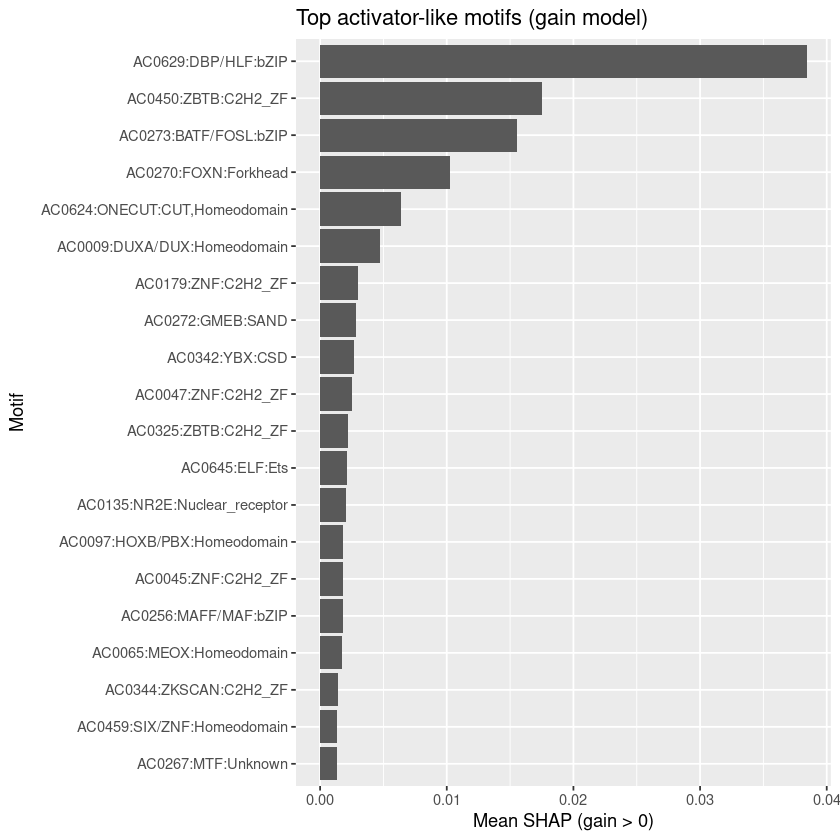

In [12]:
top_act <- dat_motif_activator %>%
  slice_max(order_by = mean_shap_nz, n = 20)

ggplot(top_act,
       aes(x = reorder(variable, mean_shap_nz),
           y = mean_shap_nz)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Motif",
    y = "Mean SHAP (gain > 0)",
    title = "Top activator-like motifs (gain model)"
  )

In [13]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_motif_activator.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_motif_activator
write_tsv(dat, txt_fpath)

## SHAP dependent plot

Summary of what you are doing conceptually

Gain model:

Features = motif gain strength (0 or >0).

Positive SHAP = “gaining this motif pushes Δ up”.

You summarise SHAP across variants to rank motifs whose gain consistently and strongly increases Δ → activator-like motifs.

Next step (later) will be symmetric:

Use the loss-flip model (features = loss magnitude, SHAP > 0 ⇒ destroying that motif increases Δ) to call repressor-like motifs, using the same kind of summary.

In [16]:
head(dat_xgb_gain_shap)

ID,variable,value,rfvalue,stdfvalue,mean_value
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,AC0629:DBP/HLF:bZIP,0.13007633,6.198104,0.6958730,0.001387135
2,AC0629:DBP/HLF:bZIP,0.13188913,6.198104,0.6958730,0.001387135
3,AC0629:DBP/HLF:bZIP,0.12323806,6.198104,0.6958730,0.001387135
4,AC0629:DBP/HLF:bZIP,0.12072817,6.198104,0.6958730,0.001387135
5,AC0629:DBP/HLF:bZIP,0.24864334,4.409525,0.4950657,0.001387135
6,AC0629:DBP/HLF:bZIP,0.07551295,6.198104,0.6958730,0.001387135


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the SHAPforxgboost package.
  Please report the issue at <https://github.com/liuyanguu/SHAPforxgboost/issues>.”
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.001452”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = par

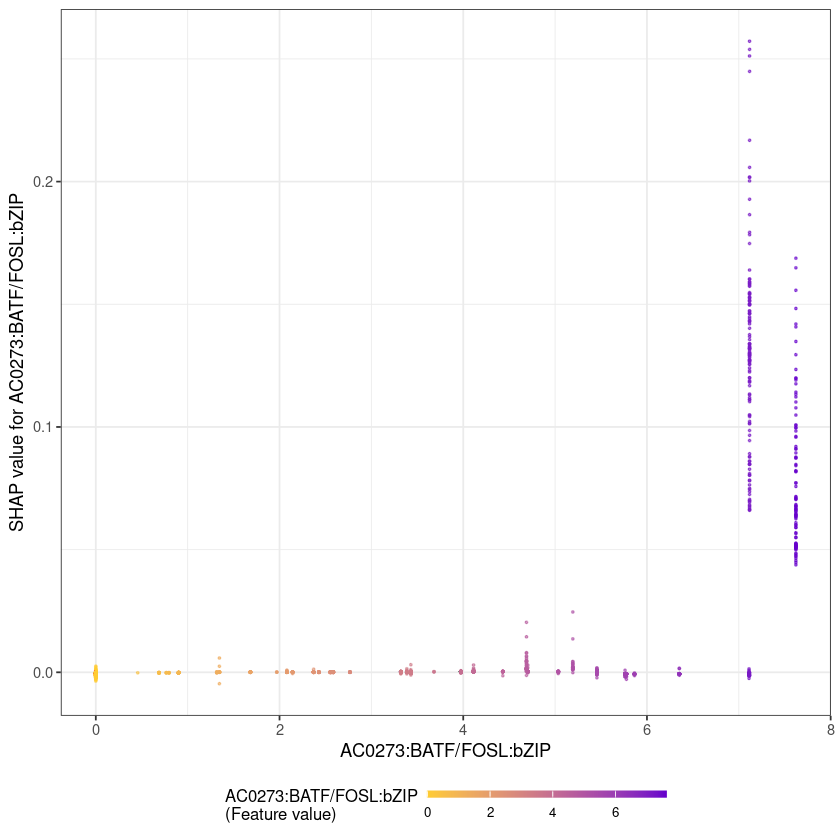

In [24]:
shap.plot.dependence(
    data_long = as.data.table(dat_xgb_gain_shap),
    x = "AC0273:BATF/FOSL:bZIP",
    color_feature = "AC0273:BATF/FOSL:bZIP"
)

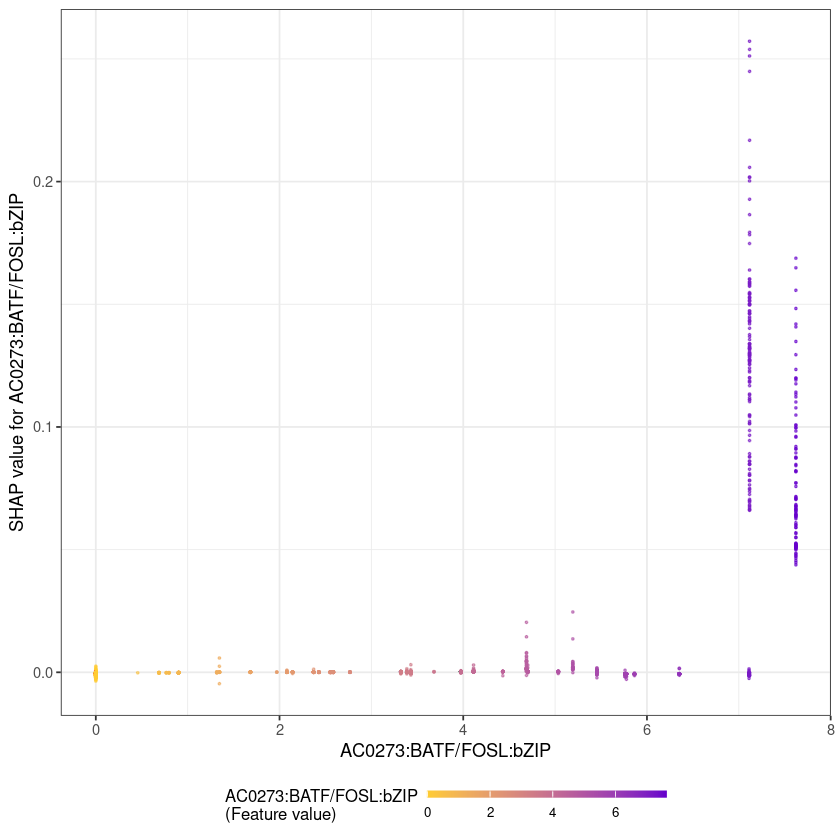

In [25]:
p <- shap.plot.dependence(
  data_long     = as.data.table(dat_xgb_gain_shap),
  x             = "AC0273:BATF/FOSL:bZIP",
  color_feature = "AC0273:BATF/FOSL:bZIP"
)

# Remove smoothing layer if present
p$layers <- p$layers[!vapply(p$layers, function(layer) {
  inherits(layer$geom, "GeomSmooth")
}, logical(1))]

print(p)

In [26]:
class(p)

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

In [ ]:
dat = dat_motif_activator
dat = dat %>% 
    tidyr::pivot_wider(
        id_cols   = variable, 
        id_expand = 
        values_from = mean_shap_nz
        